# Метрики эффективности

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from numpy.random import shuffle

In [20]:
url = "https://huggingface.co/datasets/mstz/heart/raw/main/heart.csv"
data = pd.read_csv("heart.csv")

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [21]:
print(data.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'output']


In [22]:
y = data["output"]
X = data.drop("output", axis=1)
print(X.shape, y.shape)

(303, 13) (303,)


In [23]:
logistic = LogisticRegression(max_iter=1000).fit(X, y)
print("Accuracy на всех данных:", logistic.score(X, y))

Accuracy на всех данных: 0.8481848184818482


In [24]:
N = 200
X_train = X[:N]
y_train = y[:N]
X_test = X[N:]
y_test = y[N:]

print("Обучающая выборка:", X_train.shape, y_train.shape)
print("Тестовая выборка:", X_test.shape, y_test.shape)

Обучающая выборка: (200, 13) (200,)
Тестовая выборка: (103, 13) (103,)


In [25]:
logistic_test = LogisticRegression(max_iter=1000).fit(X_train, y_train)
train_acc = logistic_test.score(X_train, y_train)
test_acc = logistic_test.score(X_test, y_test)
print("Обучающая точность:", train_acc)
print("Тестовая точность:", test_acc)

Обучающая точность: 0.905
Тестовая точность: 0.5242718446601942


In [26]:
N = int(X.shape[0] * 0.8)
X_train = X[:N]
y_train = y[:N]
X_test = X[N:]
y_test = y[N:]

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (242, 13)
Тестовая выборка: (61, 13)


In [27]:
logistic_test = LogisticRegression(max_iter=1000).fit(X_train, y_train)
train_acc = logistic_test.score(X_train, y_train)
test_acc = logistic_test.score(X_test, y_test)
print("Обучающая точность:", train_acc)
print("Тестовая точность:", test_acc)

Обучающая точность: 0.8925619834710744
Тестовая точность: 0.6229508196721312


/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [28]:
data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,output
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [29]:
N = int(X.shape[0] * 0.8)
mask = np.array([True] * N + [False] * (X.shape[0] - N))
shuffle(mask)   # перемешиваем маску

X_train = X[mask]
y_train = y[mask]
X_test = X[~mask]
y_test = y[~mask]

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (242, 13)
Тестовая выборка: (61, 13)


In [30]:
logistic_test = LogisticRegression(max_iter=1000).fit(X_train, y_train)
train_acc = logistic_test.score(X_train, y_train)
test_acc = logistic_test.score(X_test, y_test)
print("Обучающая точность:", train_acc)
print("Тестовая точность:", test_acc)

Обучающая точность: 0.8471074380165289
Тестовая точность: 0.9344262295081968


/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)
print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (242, 13)
Тестовая выборка: (61, 13)


In [32]:
logistic_test = LogisticRegression(max_iter=1000).fit(X_train, y_train)
train_acc = logistic_test.score(X_train, y_train)
test_acc = logistic_test.score(X_test, y_test)
print("Обучающая точность:", train_acc)
print("Тестовая точность:", test_acc)

Обучающая точность: 0.8636363636363636
Тестовая точность: 0.8852459016393442


In [33]:
y_train_pred = logistic_test.predict(X_train)
y_test_pred = logistic_test.predict(X_test)

In [34]:
print("Матрица классификации (обучающая выборка):")
print(confusion_matrix(y_train, y_train_pred))

Матрица классификации (обучающая выборка):
[[ 87  22]
 [ 11 122]]


In [35]:
print("Матрица классификации (тестовая выборка):")
print(confusion_matrix(y_test, y_test_pred))

Матрица классификации (тестовая выборка):
[[25  4]
 [ 3 29]]


In [36]:
print("Отчёт о классификации (тестовая выборка):")
print(classification_report(y_test, y_test_pred))

Отчёт о классификации (тестовая выборка):
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



In [37]:
metrics_df = pd.DataFrame({
    "Train": [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
    ],
    "Test": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
    ],
}, index=["Accuracy", "Precision", "Recall", "F1"])

metrics_df

,Train,Test
Accuracy,0.863636,0.885246
Precision,0.847222,0.878788
Recall,0.917293,0.906250
F1,0.880866,0.892308


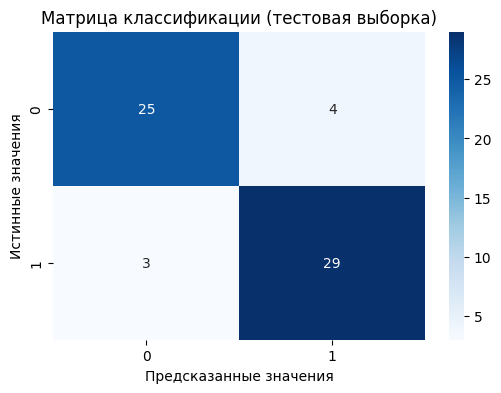

In [38]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Матрица классификации (тестовая выборка)")
plt.ylabel("Истинные значения")
plt.xlabel("Предсказанные значения")
plt.show()

# Задание для самостоятельного решения

# Задание 1:  Анализ для других видов моделей


                Model  Accuracy  Precision  Recall      F1
2        RandomForest    0.8361     0.7805  0.9697  0.8649
6          NaiveBayes    0.8197     0.7895  0.9091  0.8451
4        SVM (linear)    0.8033     0.7561  0.9394  0.8378
0  LogisticRegression    0.8033     0.7692  0.9091  0.8333
7                 MLP    0.7213     0.7222  0.7879  0.7536
1        DecisionTree    0.7049     0.7027  0.7879  0.7429
5           SVM (rbf)    0.6557     0.6500  0.7879  0.7123
3          KNeighbors    0.5902     0.6250  0.6061  0.6154


/var/folders/nx/cvp4nbcx5075w7wjhzyfgyd40000gn/T/ipykernel_95614/1891833814.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, y="Model", x="F1", palette="viridis")


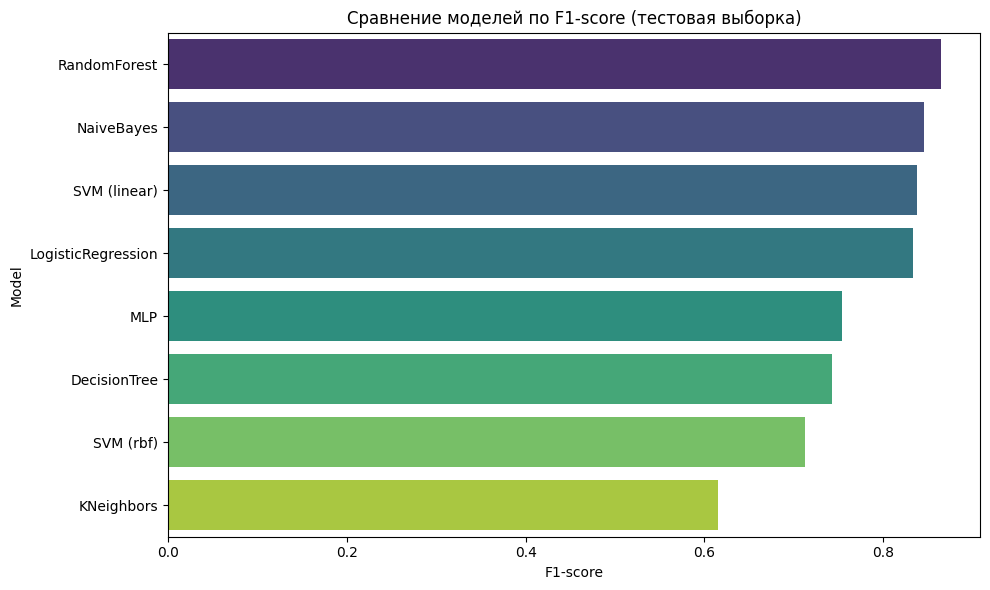

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Загрузка данных
url = "heart.csv"
df = pd.read_csv(url)

# Если столбец называется 'target', переименуем в 'output'
if 'target' in df.columns:
    df.rename(columns={'target': 'output'}, inplace=True)

X = df.drop('output', axis=1)
y = df['output']

# Разделение на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Словарь моделей
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNeighbors": KNeighborsClassifier(n_neighbors=5),
    "SVM (linear)": SVC(kernel='linear', random_state=42),
    "SVM (rbf)": SVC(kernel='rbf', random_state=42),
    "NaiveBayes": GaussianNB(),
    "MLP": MLPClassifier(max_iter=1000, random_state=42)
}

# Сбор метрик
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append([name, acc, prec, rec, f1])

# Таблица результатов
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
results_df.sort_values("F1", ascending=False, inplace=True)
print(results_df.round(4))

# График сравнения по F1
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, y="Model", x="F1", palette="viridis")
plt.title("Сравнение моделей по F1-score (тестовая выборка)")
plt.xlabel("F1-score")
plt.tight_layout()
plt.show()

# Задание 2: Анализ датасета множественная классификация

Целевые классы: ['setosa' 'versicolor' 'virginica']

LogisticRegression — classification report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


DecisionTree — classification report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


RandomForest — classification report:
               precision    recall  f1-score   support

     

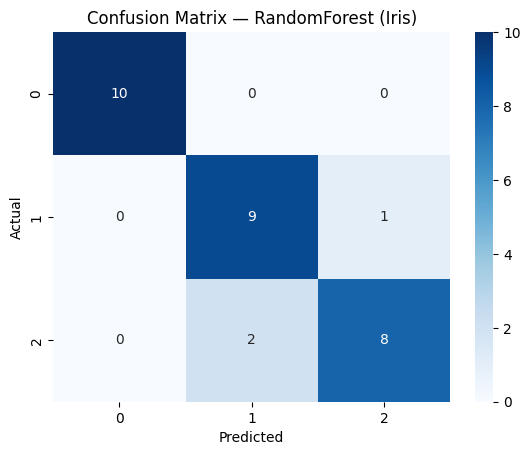

In [2]:
from sklearn.datasets import load_iris
from sklearn.metrics import classification_report, confusion_matrix

# Загрузка данных
iris = load_iris()
X = iris.data
y = iris.target
print("Целевые классы:", iris.target_names)

# Разделение
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Словарь моделей (добавим метрику 'macro')
models_iris = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNeighbors": KNeighborsClassifier(n_neighbors=5),
    "SVM (rbf)": SVC(kernel='rbf', random_state=42),
    "NaiveBayes": GaussianNB(),
    "MLP": MLPClassifier(max_iter=1000, random_state=42)
}

results_iris = []
for name, model in models_iris.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    # Для мультикласса используем macro F1
    f1_macro = f1_score(y_test, y_pred, average='macro')
    results_iris.append([name, acc, f1_macro])
    print(f"\n{name} — classification report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# Таблица сравнения
results_iris_df = pd.DataFrame(results_iris, columns=["Model", "Accuracy", "F1 (macro)"])
results_iris_df.sort_values("F1 (macro)", ascending=False, inplace=True)
print(results_iris_df.round(4))

# Визуализация матрицы ошибок для лучшей модели
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — RandomForest (Iris)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Задание 3: Анализ датасета регрессия

              Model      R²     MAE    RMSE
4      RandomForest  0.8043  0.3296  0.5064
3      DecisionTree  0.6187  0.4558  0.7069
2             Lasso  0.5845  0.5363  0.7379
1             Ridge  0.5759  0.5332  0.7455
0  LinearRegression  0.5758  0.5332  0.7456
5        KNeighbors  0.1463  0.8128  1.0577
6         SVR (rbf) -0.0165  0.8600  1.1541


/var/folders/nx/cvp4nbcx5075w7wjhzyfgyd40000gn/T/ipykernel_95614/103667810.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=reg_df, y="Model", x="R²", palette="coolwarm")


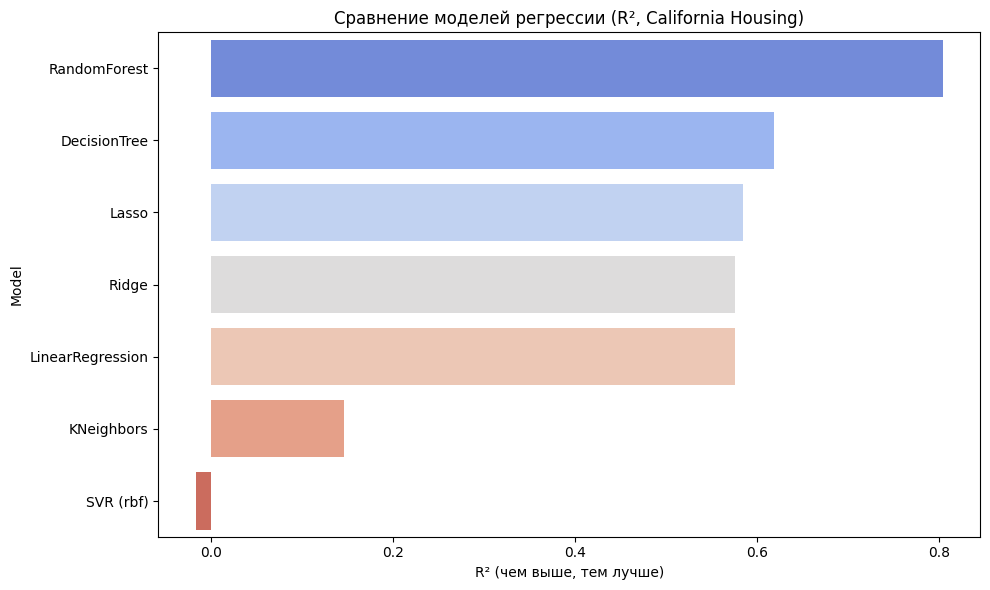

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Загрузка данных
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Разделение
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Словарь регрессионных моделей
regressors = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=5000),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=50, random_state=42),
    "KNeighbors": KNeighborsRegressor(),
    "SVR (rbf)": SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

# Сбор метрик
reg_results = []
for name, model in regressors.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    reg_results.append([name, r2, mae, rmse])

# Таблица
reg_df = pd.DataFrame(reg_results, columns=["Model", "R²", "MAE", "RMSE"])
reg_df.sort_values("R²", ascending=False, inplace=True)
print(reg_df.round(4))

# График сравнения R²
plt.figure(figsize=(10,6))
sns.barplot(data=reg_df, y="Model", x="R²", palette="coolwarm")
plt.title("Сравнение моделей регрессии (R², California Housing)")
plt.xlabel("R² (чем выше, тем лучше)")
plt.tight_layout()
plt.show()

## Пункт 1. Почему нужно применять несколько метрик эффективности?

Одна метрика даёт неполную картину. Например, на несбалансированном датасете (90% класс 0 / 10% класс 1) модель, предсказывающая всегда 0, даёт **accuracy = 0.90**, но **recall = 0** — она полностью игнорирует меньший класс. Комбинация accuracy + precision + recall + F1 позволяет обнаружить такие ситуации.

In [39]:
# Демонстрация: «тупая» модель всегда предсказывает большинство
y_dummy = np.zeros(len(y_test), dtype=int)   # всегда класс 0
print("Dummy — всегда класс 0:")
print(f"  accuracy  = {accuracy_score(y_test, y_dummy):.3f}")
print(f"  precision = {precision_score(y_test, y_dummy, zero_division=0):.3f}")
print(f"  recall    = {recall_score(y_test, y_dummy, zero_division=0):.3f}")
print(f"  f1        = {f1_score(y_test, y_dummy, zero_division=0):.3f}")
# Видно: accuracy приемлемая, но recall=0 — модель бесполезна для класса 1.

Dummy — всегда класс 0:
  accuracy  = 0.475
  precision = 0.000
  recall    = 0.000
  f1        = 0.000


## Пункт 2. Зачем делить датасет на train/test?

Оценка на **тех же данных, на которых обучали**, завышает метрики — модель «запомнила» ответы. Тестовая выборка имитирует новые данные и показывает, обобщает ли модель. Большой разрыв train > test сигнализирует о **переобучении**.

In [40]:
from sklearn.tree import DecisionTreeClassifier

# Сравниваем train-only оценку vs честную test-оценку для дерева разных глубин
for depth in [1, 3, 10, None]:
    m = DecisionTreeClassifier(max_depth=depth, random_state=0).fit(X_train, y_train)
    tr = m.score(X_train, y_train)
    te = m.score(X_test,  y_test)
    overfit = "переобучение" if tr - te > 0.1 else "норм"
    print(f"depth={str(depth):>4}  train={tr:.3f}  test={te:.3f}  [{overfit}]")

depth=   1  train=0.740  test=0.836  [норм]
depth=   3  train=0.847  test=0.820  [норм]
depth=  10  train=1.000  test=0.787  [переобучение]
depth=None  train=1.000  test=0.787  [переобучение]


## Пункт 3. Особенности и область применения каждой метрики

| Метрика | Формула | Когда важна |
|---|---|---|
| **Accuracy** | (TP+TN)/(все) | Сбалансированные классы, общая точность |
| **Precision** | TP/(TP+FP) | Дорогие ложные тревоги (спам-фильтр, реклама) |
| **Recall** | TP/(TP+FN) | Опасны пропуски (рак, мошенничество, аварии) |
| **F1** | 2·P·R/(P+R) | Несбалансированные классы, нужен баланс P и R |
| **R² (регрессия)** | 1-SS_res/SS_tot | Насколько модель объясняет дисперсию |
| **MAE** | mean\|y-ŷ\| | Интерпретируемая ошибка в единицах цели |
| **RMSE** | √MSE | Штрафует крупные ошибки сильнее MAE |

## Пункт 4. Примеры, где каждая метрика определяющая

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Синтетический пример: две «модели» классификации
y_true = np.array([1,1,1,1,1, 0,0,0,0,0])   # 5 больных, 5 здоровых

# Модель A: осторожная — много ложных тревог (высокий recall, низкий precision)
y_A = np.array([1,1,1,1,1, 1,1,0,0,0])
# Модель B: точная — мало ложных тревог (высокий precision, низкий recall)
y_B = np.array([1,1,0,0,0, 0,0,0,0,0])

for name, yp in [("A (осторожная)", y_A), ("B (точная)", y_B)]:
    print(f"Модель {name}:")
    print(f"  accuracy={accuracy_score(y_true,yp):.2f}  "
          f"precision={precision_score(y_true,yp):.2f}  "
          f"recall={recall_score(y_true,yp):.2f}  "
          f"f1={f1_score(y_true,yp):.2f}")
print()
print("→ Для диагностики рака важнее RECALL (не пропустить больного) → модель A.")
print("→ Для спам-фильтра важнее PRECISION (не блокировать нужные письма) → модель B.")

# Синтетический пример: регрессия
y_reg  = np.array([100., 200., 300., 400., 500.])
yp_reg1 = y_reg + 10          # равномерная ошибка
yp_reg2 = y_reg.copy(); yp_reg2[-1] += 200  # один большой выброс

print("\nРегрессия — MAE vs RMSE:")
for name, yp in [("равномерная ошибка", yp_reg1), ("один выброс", yp_reg2)]:
    print(f"  {name}: MAE={mean_absolute_error(y_reg,yp):.1f}  "
          f"RMSE={mean_squared_error(y_reg,yp)**.5:.1f}")
print("→ RMSE сильнее штрафует выброс → для задач где выброс критичен (прогноз нагрузки) → RMSE.")

Модель A (осторожная):
  accuracy=0.80  precision=0.71  recall=1.00  f1=0.83
Модель B (точная):
  accuracy=0.70  precision=1.00  recall=0.40  f1=0.57

→ Для диагностики рака важнее RECALL (не пропустить больного) → модель A.
→ Для спам-фильтра важнее PRECISION (не блокировать нужные письма) → модель B.

Регрессия — MAE vs RMSE:
  равномерная ошибка: MAE=10.0  RMSE=10.0
  один выброс: MAE=40.0  RMSE=89.4
→ RMSE сильнее штрафует выброс → для задач где выброс критичен (прогноз нагрузки) → RMSE.


## Пункт 5. Когда нельзя делить выборку случайным образом?

**Нельзя** случайно разбивать:
1. **Временные ряды** — будущее не должно попасть в train, иначе «утечка» данных (data leakage).
2. **Несбалансированные классы** — без `stratify` тестовая выборка может не содержать редкого класса.
3. **Групповые данные** — наблюдения одного пациента/пользователя нельзя расщеплять по разным выборкам.
4. **Пространственные данные** — соседние точки коррелированы; нужно пространственное разбиение.

In [42]:
# Демонстрация stratify: гарантирует те же пропорции классов в train и test
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y)

print("Пропорции классов в исходных данных:  ", y.value_counts(normalize=True).to_dict())
print("train (stratify):                     ", dict(pd.Series(y_tr_s).value_counts(normalize=True).round(3)))
print("test  (stratify):                     ", dict(pd.Series(y_te_s).value_counts(normalize=True).round(3)))

Пропорции классов в исходных данных:   {1: 0.5445544554455446, 0: 0.45544554455445546}
train (stratify):                      {1: np.float64(0.545), 0: np.float64(0.455)}
test  (stratify):                      {1: np.float64(0.541), 0: np.float64(0.459)}


## Пункт 6. Отчёт о классификации — как использовать и интерпретировать

                  precision    recall  f1-score   support

нет приступа (0)       0.88      0.82      0.85        28
     приступ (1)       0.86      0.91      0.88        33

        accuracy                           0.87        61
       macro avg       0.87      0.87      0.87        61
    weighted avg       0.87      0.87      0.87        61



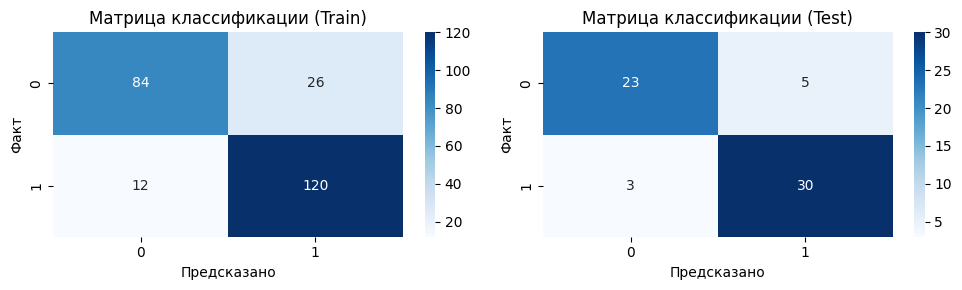

In [43]:
model_final = LogisticRegression(max_iter=1000).fit(X_tr_s, y_tr_s)
y_te_pred = model_final.predict(X_te_s)

print(classification_report(y_te_s, y_te_pred,
                             target_names=["нет приступа (0)", "приступ (1)"]))
# Интерпретация столбцов:
# precision — из всех предсказанных как класс X, сколько действительно X
# recall    — из всех реальных X, сколько мы нашли
# f1-score  — гармоническое среднее precision и recall
# support   — количество реальных объектов класса в тестовой выборке
# macro avg — среднее по классам (без учёта размера)
# weighted avg — среднее с весом по support

# Визуализация матрицы ошибок
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, (split_name, yt, yp) in zip(axes, [
        ("Train", y_tr_s, model_final.predict(X_tr_s)),
        ("Test",  y_te_s, y_te_pred)]):
    sns.heatmap(confusion_matrix(yt, yp), annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f"Матрица классификации ({split_name})")
    ax.set_xlabel("Предсказано"); ax.set_ylabel("Факт")
plt.tight_layout(); plt.show()